In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sb
import pingouin as pg
import warnings 
warnings.filterwarnings('ignore', category=FutureWarning)

In [9]:
img_format='svg'
mpl.rcParams['svg.fonttype'] = 'none'
save_path = '/Users/amonast/BOSTON UNIVERSITY Dropbox/Amy Monasterio/Manuscripts/Engram2P/Figures/RevisionFigures/Figure3_Supp4/plots'

In [10]:
df1 = pd.read_csv('/Volumes/AM_SSD1/Spont2P/Analysis/correlation/mean_population_velocity_correlation_Post.csv')
df2 = pd.read_csv('/Volumes/AM_SSD1/Spont2P/Analysis/correlation/mean_population_velocity_correlation_Baseline.csv')
df = pd.concat([df1,df2],ignore_index=True)

df_long = pd.melt(
    df,
    id_vars=['animal', 'fov', 'group', 'session'],
    value_vars=['mean_non', 'mean_engram'],
    var_name='Population',
    value_name='Correlation')

ensemble_colors = {'mean_engram': '#F37243','mean_non': '#00ABC8'}

                 Source        SS  ddof1  ddof2        MS         F     p-unc  \
0               session  0.014435      1      6  0.014435  1.819962  0.226001   
1            Population  0.061003      1      6  0.061003  9.050212  0.023751   
2  session * Population  0.008940      1      6  0.008940  1.734971  0.235843   

   p-GG-corr       ng2  eps  
0   0.226001  0.031471  1.0  
1   0.023751  0.120742  1.0  
2   0.235843  0.019729  1.0  
               Contrast   session            A         B Paired  Parametric  \
0               session         -     Baseline      Post   True        True   
1            Population         -  mean_engram  mean_non   True        True   
2  session * Population  Baseline  mean_engram  mean_non   True        True   
3  session * Population      Post  mean_engram  mean_non   True        True   

          T  dof alternative     p-unc    p-corr p-adjust    BF10    hedges  
0 -1.349060  6.0   two-sided  0.226001       NaN      NaN   0.689 -0.341064  
1 -

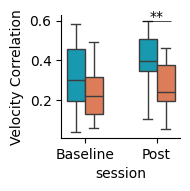

In [11]:

FC = df_long.loc[df_long['group']=='FC']
plt.figure(figsize=(2,2))
sb.boxplot(data=FC,x='session',order=['Baseline','Post'],
           hue='Population',y='Correlation',palette=ensemble_colors,
           width=0.5,showfliers=False)
#sb.pointplot(data=FC,x='session',hue='Population',hue='Population',y='Correlation',color=(0.4,.4,.4),hue='animal',markersize=2,linewidth=1)
plt.hlines(.6,.8,1.2,color='k',linewidth=.5)
plt.text(1,0.6,'**',ha='center')
plt.legend().remove()
plt.ylabel('Velocity Correlation')
sb.despine()
plt.tight_layout()

print(pg.rm_anova(data=FC,dv='Correlation',
                  within=['session','Population'],subject='animal'))
print(pg.pairwise_tests(data=FC,dv='Correlation',
                        within=['session','Population'],subject='animal',
                        padjust='fdr_bh'))
#plt.savefig(f"{save_path}/FC_popcorr_velocity_boxplot.svg",transparent=True)

                 Source        SS  ddof1  ddof2        MS         F     p-unc  \
0               session  0.009516      1      5  0.009516  0.793376  0.413883   
1            Population  0.035934      1      5  0.035934  9.441633  0.027698   
2  session * Population  0.000006      1      5  0.000006  0.005625  0.943121   

   p-GG-corr       ng2  eps  
0   0.413883  0.028105  1.0  
1   0.027698  0.098448  1.0  
2   0.943121  0.000019  1.0  
               Contrast   session            A         B Paired  Parametric  \
0               session         -     Baseline      Post   True        True   
1            Population         -  mean_engram  mean_non   True        True   
2  session * Population  Baseline  mean_engram  mean_non   True        True   
3  session * Population      Post  mean_engram  mean_non   True        True   

          T  dof alternative     p-unc    p-corr p-adjust   BF10    hedges  
0  0.890717  5.0   two-sided  0.413883       NaN      NaN  0.508  0.298004  
1 -3.

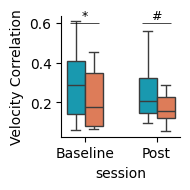

In [12]:

#%%
HC = df_long.loc[df_long['group']=='HC']
plt.figure(figsize=(2,2))
sb.boxplot(data=HC,x='session',order=['Baseline','Post'],
           hue='Population',
           y='Correlation',palette=ensemble_colors,
           width=0.5,showfliers=False)
#sb.pointplot(data=HC,x='session',hue='Population',y='Correlation',color=(0.4,.4,.4),markersize=2,linewidth=1)

plt.legend().remove()
plt.hlines(.6,.8,1.2,color='k',linewidth=.5)
plt.text(1,0.62,'#',ha='center',size=9)
plt.hlines(.6,-.2,.2,color='k',linewidth=.5)
plt.text(0,0.62,'*',ha='center',size=9)
plt.ylabel('Velocity Correlation')
sb.despine()
plt.tight_layout()
#plt.savefig(f"{save_path}/HC_popcorr_velocity_boxplot.svg",transparent=True)
print(pg.rm_anova(data=HC,dv='Correlation',
                  within=['session','Population'],subject='animal'))
print(pg.pairwise_tests(data=HC,dv='Correlation',
                        within=['session','Population'],subject='animal',
                        padjust='fdr_bh'))
# %%

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_92442/3564985234.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  a.set_xticklabels(["D0","D4"])


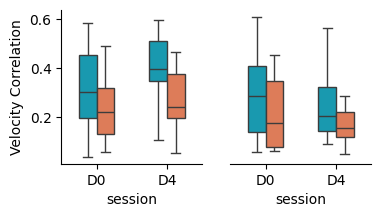

In [13]:

#%%
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(4,2),sharey=True,)
sb.boxplot(data=FC,x='session',order=['Baseline','Post'],ax=ax[0],
           hue='Population',y='Correlation',palette=ensemble_colors,
           width=0.5,showfliers=False,legend=False)
sb.boxplot(data=HC,x='session',order=['Baseline','Post'],ax=ax[1],
           hue='Population',y='Correlation',palette=ensemble_colors,
           width=0.5,showfliers=False,legend=False)
for a in ax: 
    a.set_xticklabels(["D0","D4"])
sb.despine()
ax[0].set_ylabel('Velocity Correlation')
ax[1].tick_params(left=False,labelleft=False)
ax[1].yaxis.set_visible(False)
ax[1].spines["left"].set_visible(False)
ax[1].set_ylabel("")

plt.savefig(f'/Users/amonast/BOSTON UNIVERSITY Dropbox/Amy Monasterio/'
            f'Manuscripts/Engram2P/Figures/RevisionFigures/Round2/Fig3F_velocitycorr_boxplots.svg',
            transparent=True)


In [22]:
# %%
import pandas as pd
import statsmodels.formula.api as smf

df_both = pd.concat([FC, HC], ignore_index=True)
# random-effect ID = animal_FOV
df_both["subj"] = df_both["animal"].astype(str) + "_" + df_both["fov"].astype(str)
# keep only complete cases used by the model
df_both = df_both.dropna(subset=["Correlation", "Population", "group", "subj"]).reset_index(drop=True)
# categorical coding + reference levels
df_both["Population"] = df_both["Population"].astype("category")
df_both["group"] = df_both["group"].astype("category")
df_both["session"] = df_both["session"].astype("category")

df_both["Population"] = df_both["Population"].cat.reorder_categories(
    ["mean_non", "mean_engram"], ordered=False
)
df_both["group"] = df_both["group"].cat.reorder_categories(
    ["HC", "FC"], ordered=False
)

# mixed model with random intercept for subj
model = smf.mixedlm(
    "Correlation ~  group * session * Population",
    data=df_both,
    groups=df_both["subj"]).fit()

print(model.summary())

                             Mixed Linear Model Regression Results
Model:                         MixedLM              Dependent Variable:              Correlation
No. Observations:              87                   Method:                          REML       
No. Groups:                    22                   Scale:                           0.0094     
Min. group size:               3                    Log-Likelihood:                  44.4406    
Max. group size:               4                    Converged:                       Yes        
Mean group size:               4.0                                                              
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              0.298

In [23]:
df_both['subj'].loc[df_both['group']=='FC'].unique()

array(['989N_FOV1', '9972R_FOV1', '149L_FOV1', '160R_FOV1', '492N_FOV1',
       '493R_FOV1', '989N_FOV2', '9972R_FOV2', '149L_FOV2', '146R_FOV2',
       '160R_FOV2', '492N_FOV2'], dtype=object)

In [26]:
df_both['subj'].loc[df_both['group']=='HC'].unique()

array(['994R_FOV1', '217R_FOV1', '217N_FOV1', '218L_FOV1', '034R_FOV1',
       '1912L_FOV1', '994R_FOV2', '217N_FOV2', '218L_FOV2', '1912L_FOV2'],
      dtype=object)